Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow import log_metric, log_param, log_artifact
import joblib
import mlflow_logger

In [2]:
df = pd.read_csv("D:\Marwan\ITI AI&ML\Week 16\ML1 & ML Flow Project\hand_landmarks_data.csv")

In [3]:
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
df.columns

Index(['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4',
       'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8',
       'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12',
       'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15',
       'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
       'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'x21', 'y21', 'z21', 'label'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [6]:
df.shape

(25675, 64)

There is no null values dataset is cleaned

In [7]:
df.isna().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

Data preprocessing

In [8]:
def preprocess_hand_landmarks(row):

    landmarks = row.values.reshape(21, 3)
    wrist = landmarks[0]
    landmarks[:, 0] -= wrist[0]
    landmarks[:, 1] -= wrist[1]
    mid_finger_tip = landmarks[12]
    scale_factor = np.linalg.norm(mid_finger_tip[:2])
    
    if scale_factor > 0:
        landmarks[:, :2] /= scale_factor
    
    return landmarks.flatten()

X_raw = df.drop('label', axis=1)
y = df['label']

X_processed = X_raw.apply(preprocess_hand_landmarks, axis=1, result_type='expand')

In [9]:
X_processed

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,0.0,0.0,-3.649205e-07,-0.169097,-0.328246,0.004224,-0.508248,-0.501843,0.005798,-0.846234,...,-0.013198,-1.266027,-0.058407,-0.020450,-1.533293,0.026072,-0.024577,-1.759842,0.074168,-0.026722
1,0.0,0.0,-2.345265e-07,-0.040618,-0.498120,-0.011102,0.191551,-0.982869,-0.021096,0.349889,...,-0.029042,1.397837,-0.121412,-0.038175,1.691695,-0.091952,-0.037336,1.966655,-0.086635,-0.036136
2,0.0,0.0,-2.417307e-07,0.172978,-0.420554,-0.000184,0.437913,-0.820949,-0.009687,0.621006,...,-0.041256,1.404373,0.187884,-0.044068,1.676609,0.247919,-0.040469,1.913833,0.270275,-0.038301
3,0.0,0.0,-1.233261e-07,-0.020056,-0.468103,-0.002824,0.070355,-0.911821,-0.008911,0.114792,...,-0.021804,1.280797,-0.094800,-0.027622,1.529073,-0.079763,-0.027863,1.738331,-0.086693,-0.027723
4,0.0,0.0,-1.622995e-07,-0.009611,-0.482677,-0.002884,0.111650,-1.075914,-0.008115,0.131602,...,-0.021623,1.327537,-0.331511,-0.025113,1.612488,-0.386821,-0.024087,1.849127,-0.464123,-0.023486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25670,0.0,0.0,4.323656e-07,0.114793,-0.193924,0.007132,0.098020,-0.383878,0.004480,-0.017284,...,-0.033732,-0.269009,-0.453257,-0.028861,-0.231440,-0.407954,-0.016911,-0.206572,-0.351443,-0.006697
25671,0.0,0.0,3.808555e-07,-0.125252,-0.180124,0.003778,-0.111937,-0.350482,-0.001519,-0.006770,...,-0.042692,0.261348,-0.444110,-0.043690,0.221988,-0.401492,-0.029510,0.197415,-0.341976,-0.015630
25672,0.0,0.0,5.912488e-07,0.138234,-0.145323,0.001354,0.146471,-0.315521,-0.001674,0.078645,...,-0.033021,-0.188357,-0.373106,-0.031740,-0.161311,-0.323239,-0.021970,-0.141828,-0.275497,-0.010803
25673,0.0,0.0,4.319564e-07,-0.075890,-0.182773,0.006174,-0.025361,-0.356612,0.001893,0.096384,...,-0.044705,0.372312,-0.382523,-0.046297,0.348274,-0.321332,-0.032800,0.302285,-0.274486,-0.020277


There is 18 different classes

In [10]:
y

0                   call
1                   call
2                   call
3                   call
4                   call
              ...       
25670    two_up_inverted
25671    two_up_inverted
25672    two_up_inverted
25673    two_up_inverted
25674    two_up_inverted
Name: label, Length: 25675, dtype: object

In [11]:
y.unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [12]:
len(y.unique())

18

Dataset is balanced 

In [13]:
y.value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

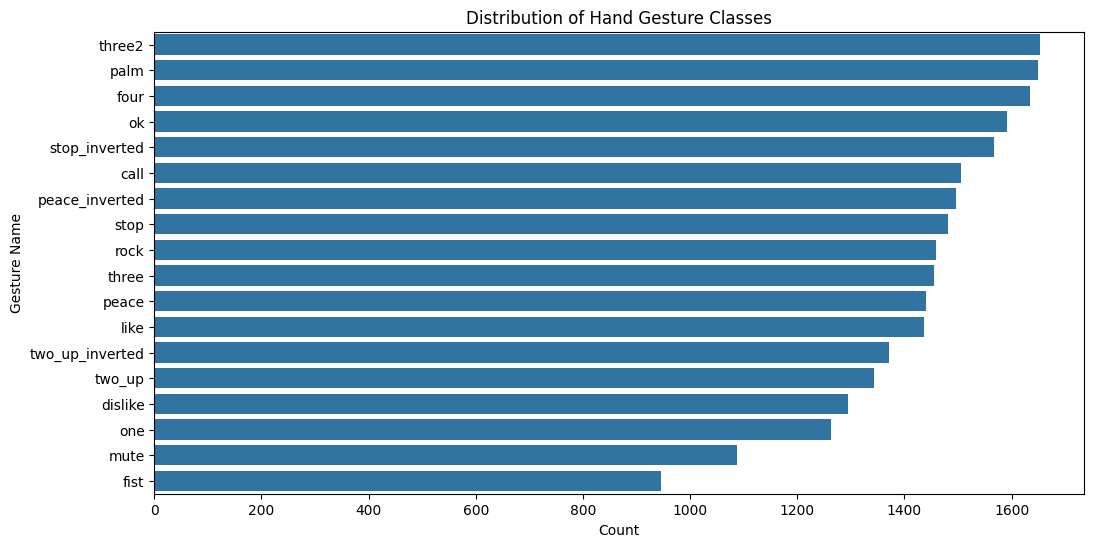

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(y=df['label'], order=df['label'].value_counts().index)
plt.title("Distribution of Hand Gesture Classes")
plt.xlabel("Count")
plt.ylabel("Gesture Name")
plt.show()

Visualization of each class shape

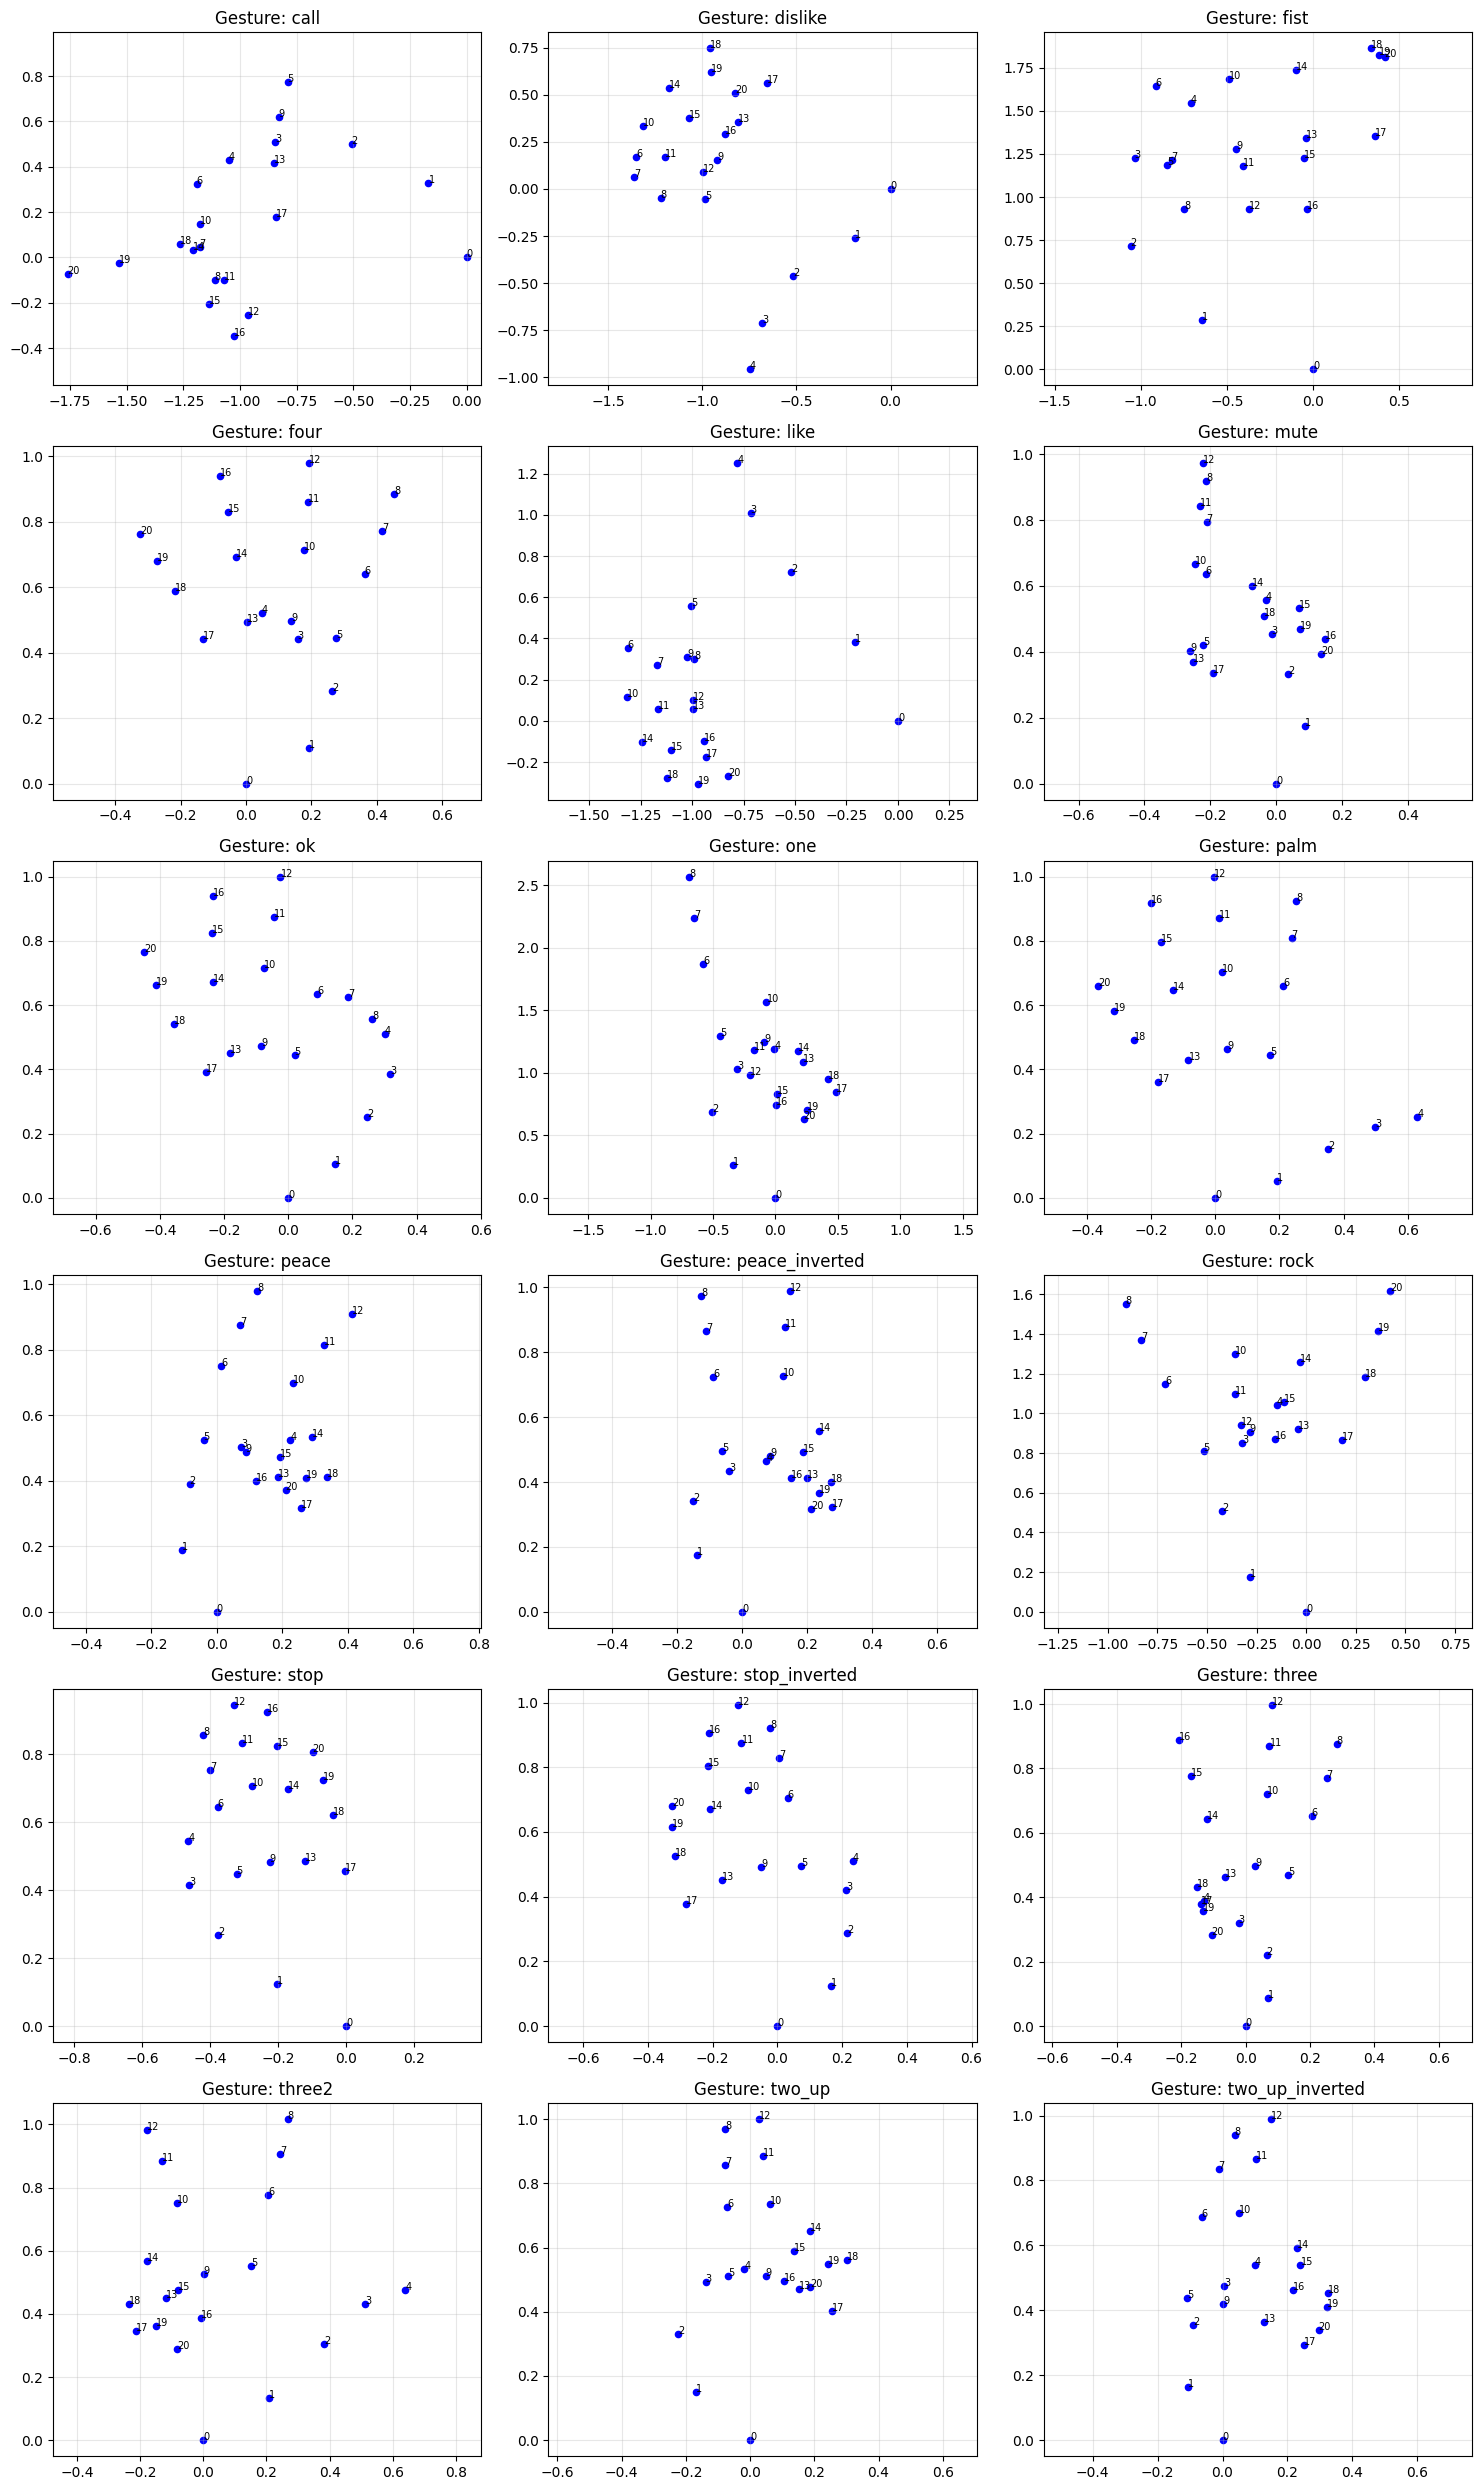

In [15]:
def plot_all_gestures(df):
    classes = df['label'].unique()
    num_classes = len(classes)
    fig, axes = plt.subplots(6, 3, figsize=(15, 25))
    axes = axes.flatten()

    for i, gesture in enumerate(classes):
        sample = df[df['label'] == gesture].iloc[0, :-1].values
        landmarks = sample.reshape(21, 3)
        
        wrist = landmarks[0]
        landmarks[:, 0] -= wrist[0]
        landmarks[:, 1] -= wrist[1]
        
        scale = np.linalg.norm(landmarks[12, :2])
        if scale > 0:
            landmarks[:, :2] /= scale

        ax = axes[i]
        ax.scatter(landmarks[:, 0], -landmarks[:, 1], c='blue', s=20) 
        
        for idx, (x, y, z) in enumerate(landmarks):
            ax.text(x, -y, str(idx), fontsize=7)
            
        ax.set_title(f"Gesture: {gesture}")
        ax.axis('equal')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_all_gestures(df)

Data splitting 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 20540
Testing samples: 5135


Logestic Regression Model

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred)

metrics = {
    "accuracy": lr_acc,
    "precision": precision_score(y_test, y_pred, average='weighted'),
    "recall": recall_score(y_test, y_pred, average='weighted'),
    "f1_score": f1_score(y_test, y_pred, average='weighted')
}

params = {
    "max_iter": 1000,
    "solver": "lbfgs",
    "model_type": "LogisticRegression"
}

In [18]:
import importlib
import mlflow_logger
import os
importlib.reload(mlflow_logger)
from mlflow_logger import log_experiment, setup_mlflow
os.environ["LOGNAME"] = "Marwan Tamer"
setup_mlflow()

MLflow Tracking URI set to: sqlite:///mlflow_research.db
Active Experiment: Hand_Gesture_Classification


In [19]:
import mlflow
print(f"Current Tracking URI: {mlflow.get_tracking_uri()}")

Current Tracking URI: sqlite:///mlflow_research.db


In [22]:
class_names = np.array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
                        'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
                        'three', 'three2', 'two_up', 'two_up_inverted'])

C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\1467359103.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:38:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:38:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'Logistic_Regression_Final' with metrics, signature, dataset, and artifacts.


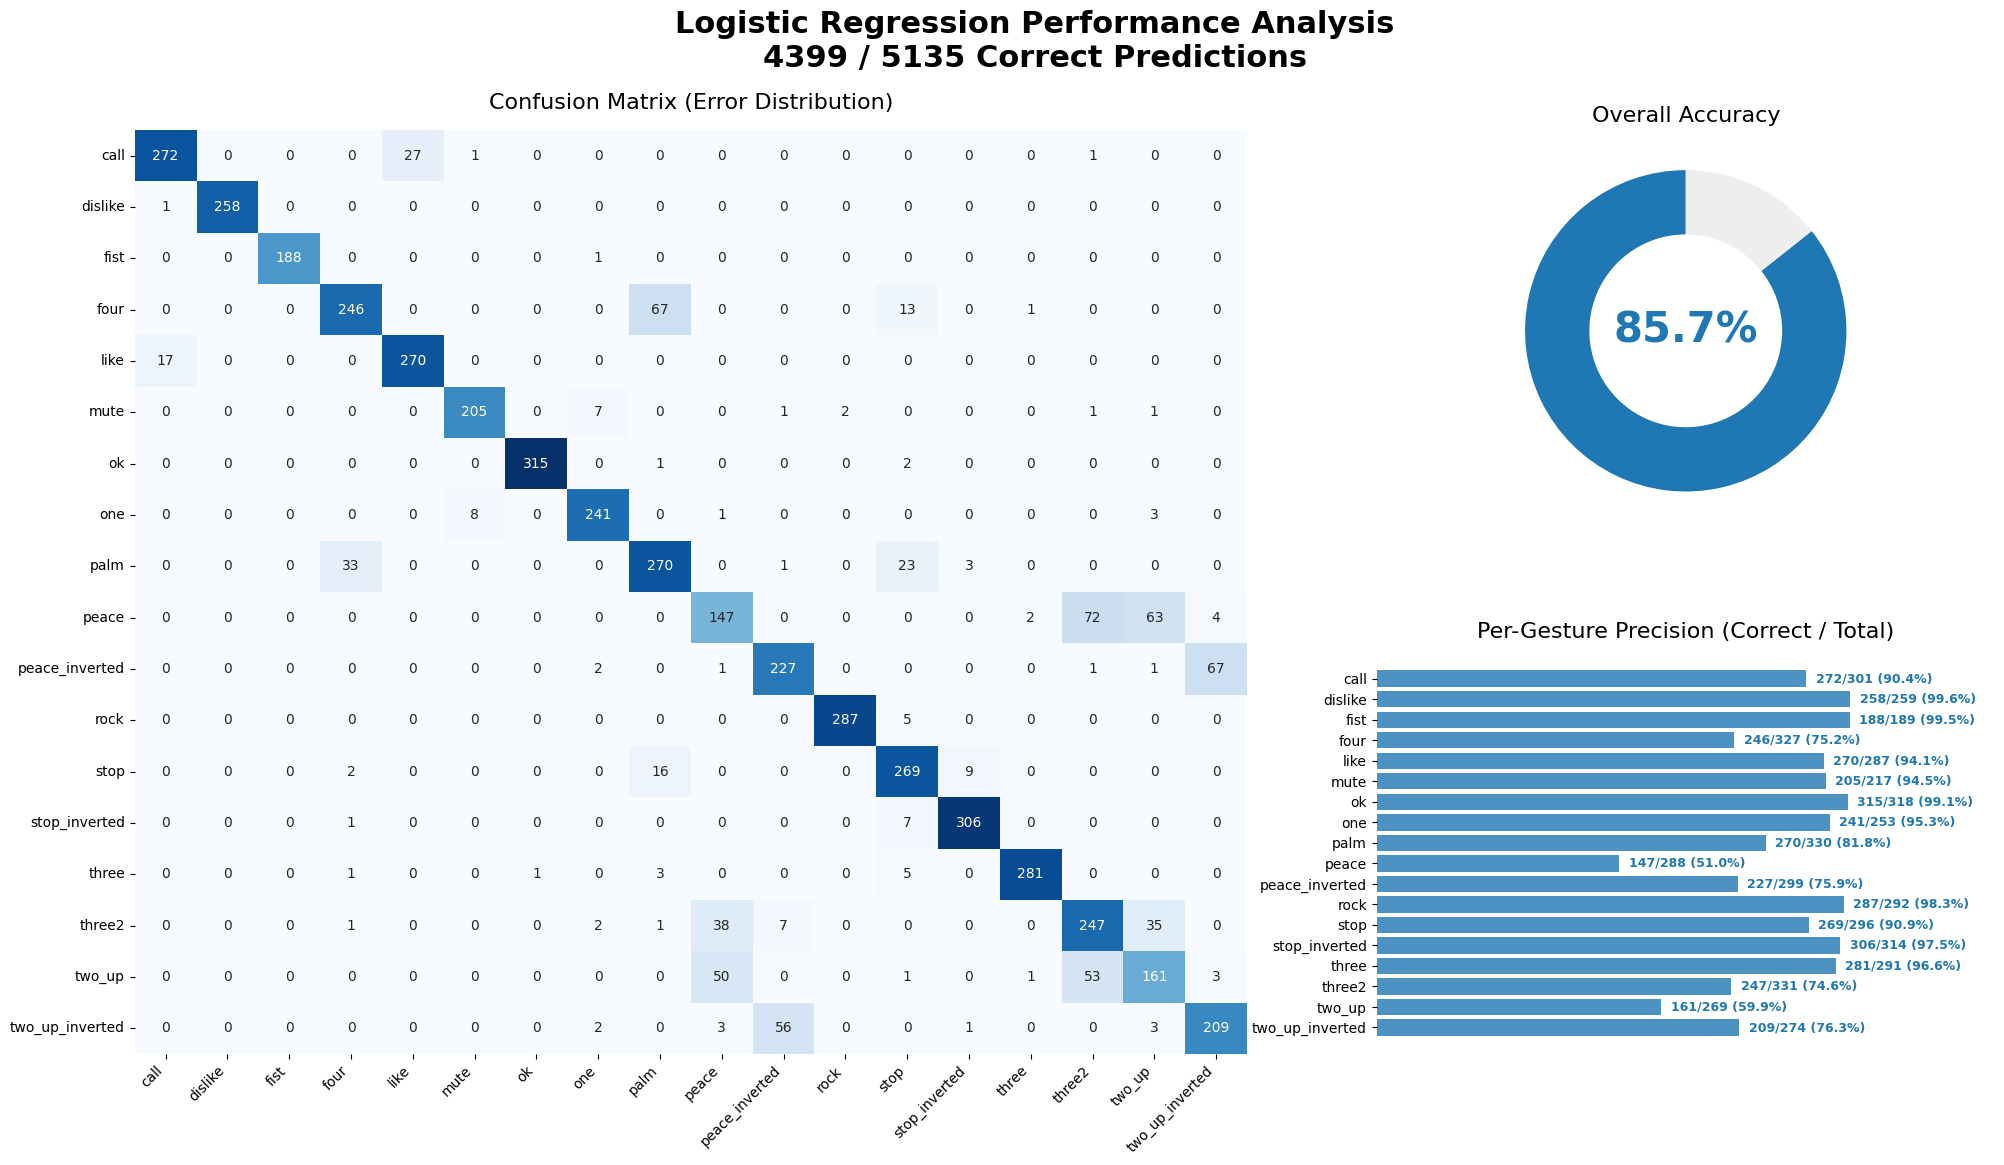

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"Logistic Regression Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#1f77b4', '#eeeeee']
ax2.pie([lr_acc, 1-lr_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{lr_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#1f77b4')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#1f77b4', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#1f77b4')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="Logistic_Regression_Final",
    model=lr_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=params,
    metrics=metrics,
    fig=fig,
    fig_name="lr_final_dashboard.png"
)

plt.show()

Decision Tree model

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

dt_metrics = {
    "accuracy": dt_acc,
    "precision": precision_score(y_test, y_pred_dt, average='weighted'),
    "recall": recall_score(y_test, y_pred_dt, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_dt, average='weighted')
}

dt_params = {
    "random_state": 42,
    "model_type": "DecisionTree"
}

C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\827574476.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:40:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:40:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'Decision_Tree_Baseline' with metrics, signature, dataset, and artifacts.


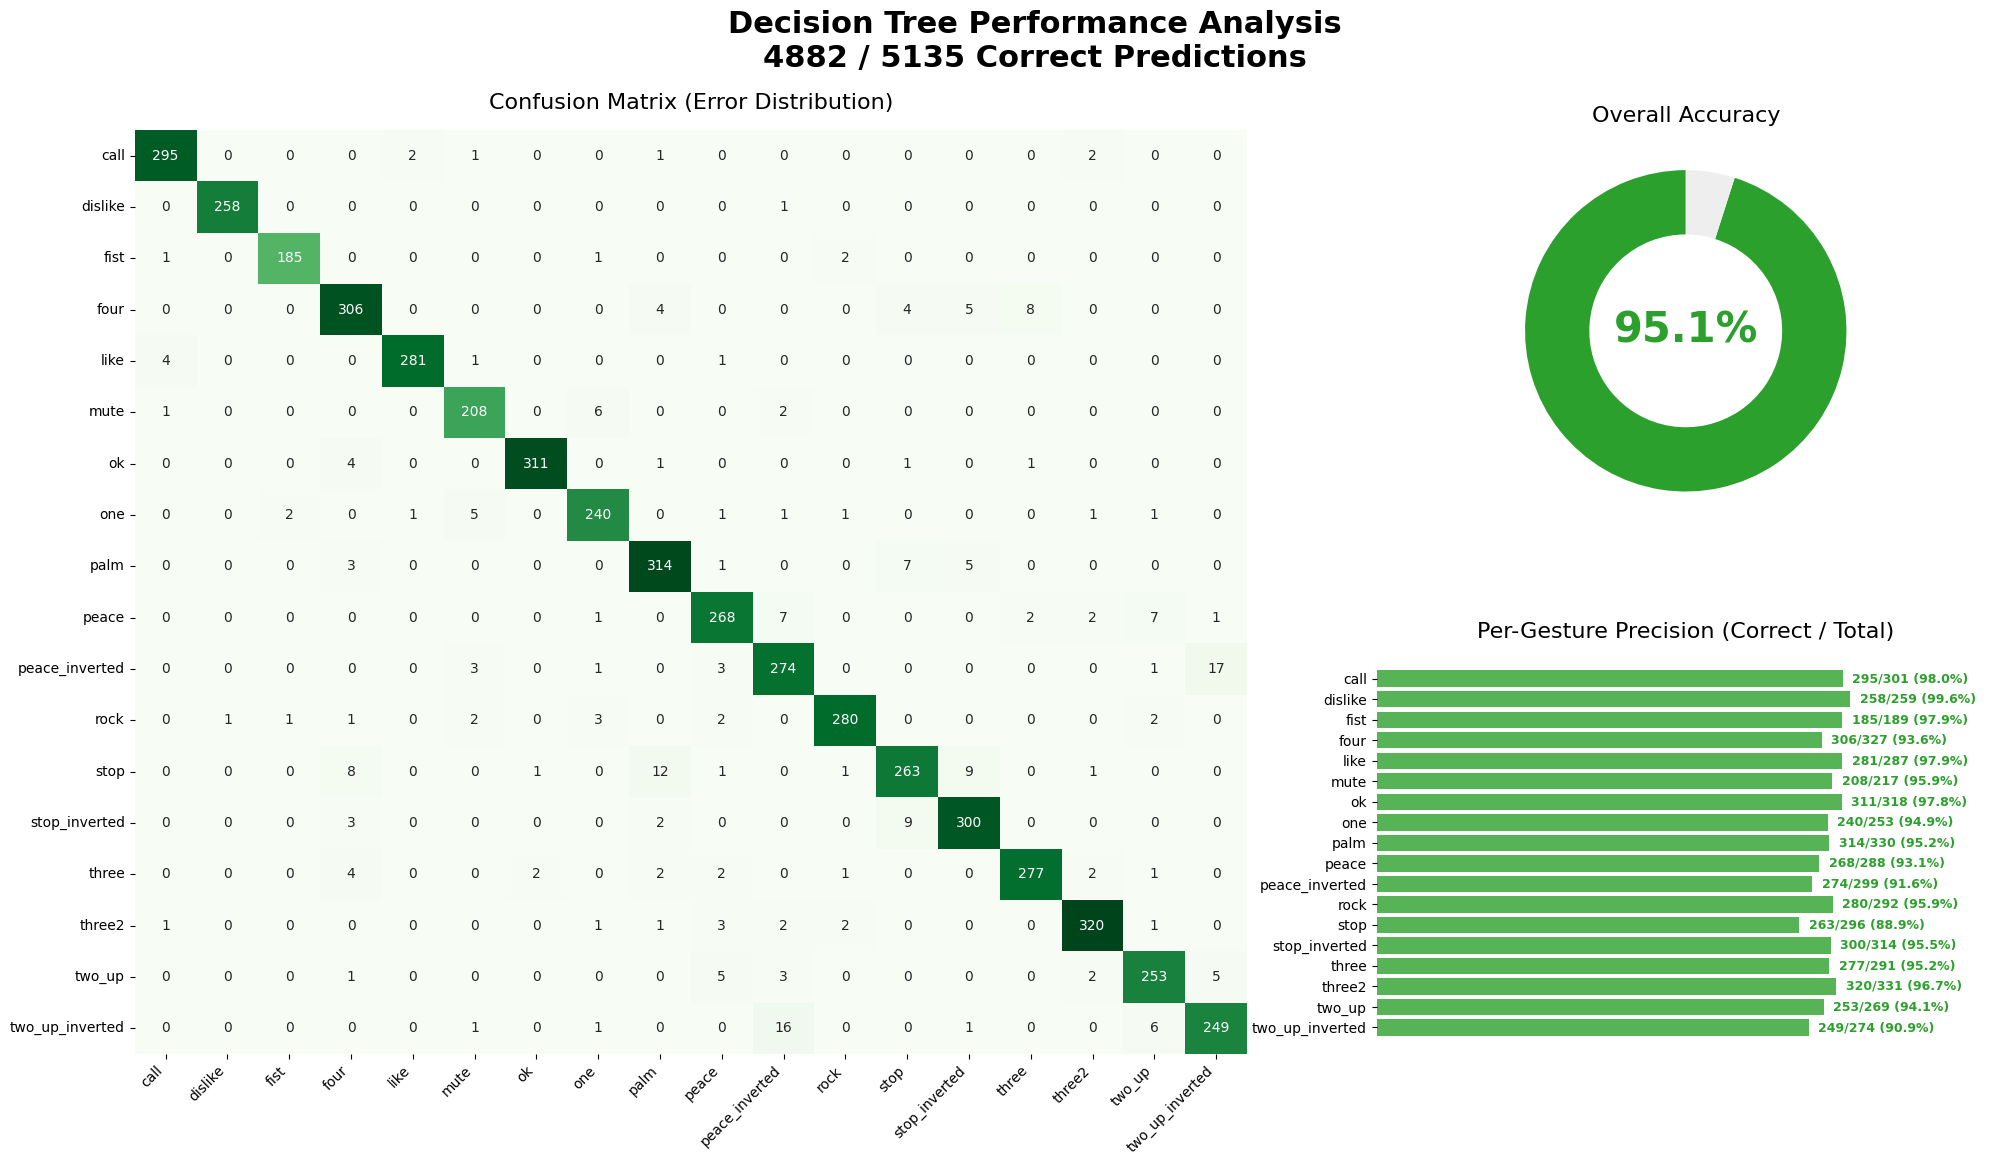

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"Decision Tree Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ca02c', '#eeeeee']
ax2.pie([dt_acc, 1-dt_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{dt_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#2ca02c')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#2ca02c', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#2ca02c')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="Decision_Tree_Baseline",
    model=dt_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=dt_params,
    metrics=dt_metrics,
    fig=fig,
    fig_name="dt_final_dashboard.png"
)
plt.show()

Random Forest Model

In [32]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

rf_model = grid_search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

rf_metrics = {
    "accuracy": rf_acc,
    "precision": precision_score(y_test, y_pred_rf, average='weighted'),
    "recall": recall_score(y_test, y_pred_rf, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_rf, average='weighted')
}

rf_params = grid_search_rf.best_params_
rf_params["model_type"] = "RandomForest_Optimized"

print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200, 'model_type': 'RandomForest_Optimized'}
Random Forest Accuracy: 0.9788


C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\3403750114.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:42:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:42:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'Random_Forest_Optimized' with metrics, signature, dataset, and artifacts.


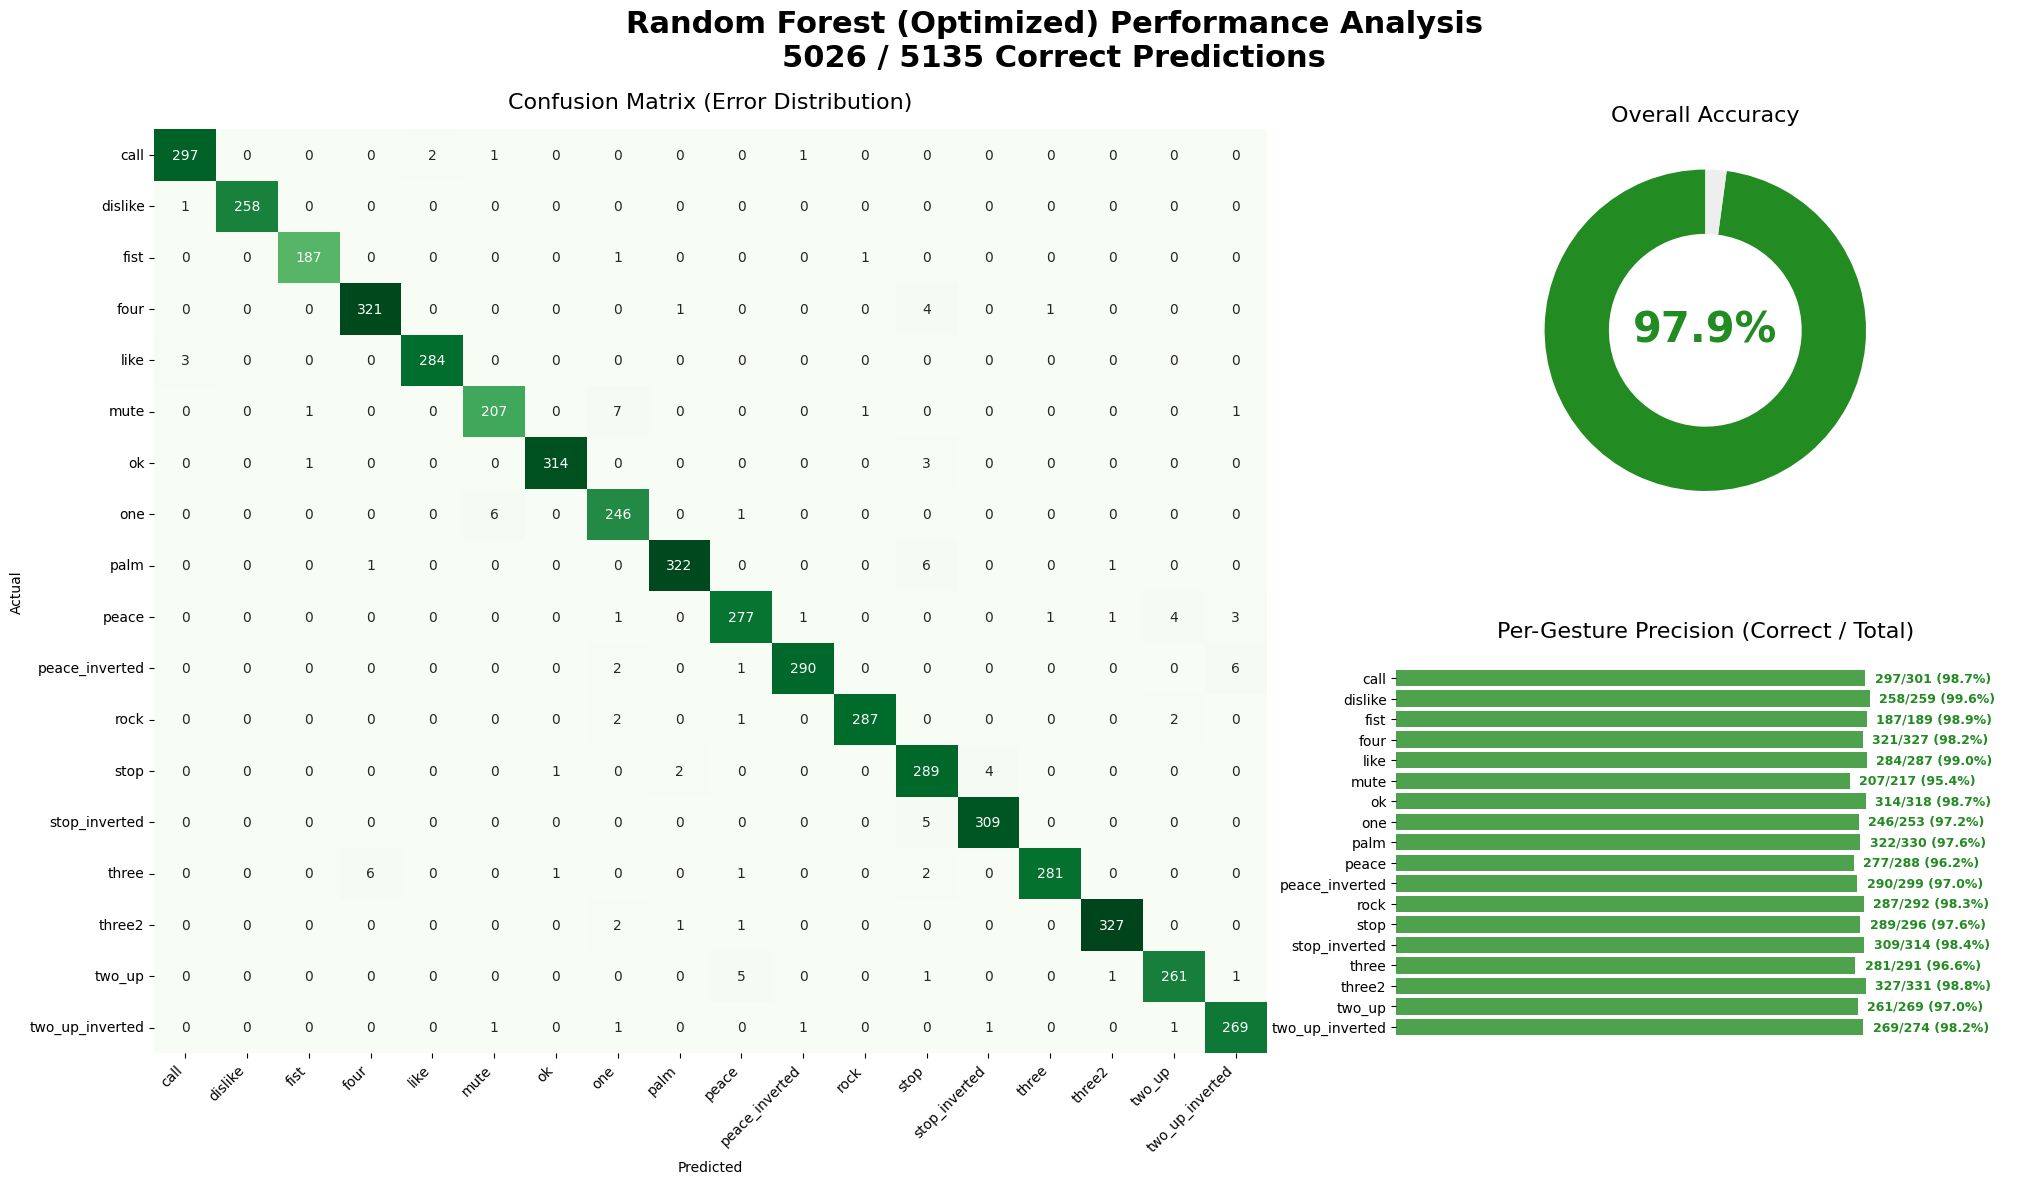

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"Random Forest (Optimized) Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#228b22', '#eeeeee']
ax2.pie([rf_acc, 1-rf_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{rf_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#228b22')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#228b22', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#228b22')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="Random_Forest_Optimized",
    model=rf_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=rf_params,
    metrics=rf_metrics,
    fig=fig,
    fig_name="rf_final_dashboard.png"
)

plt.show()

SVM Model

In [34]:
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

svm_metrics = {
    "accuracy": svm_acc,
    "precision": precision_score(y_test, y_pred_svm, average='weighted'),
    "recall": recall_score(y_test, y_pred_svm, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_svm, average='weighted')
}

svm_params = {
    "kernel": "rbf",
    "C": 1.0,
    "random_state": 42,
    "model_type": "SVM"
}

print(f"SVM Results:")
print(f"Accuracy: {svm_acc:.4f}")

SVM Results:
Accuracy: 0.9334


C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\3967233168.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:44:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:44:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'SVM_Baseline' with metrics, signature, dataset, and artifacts.


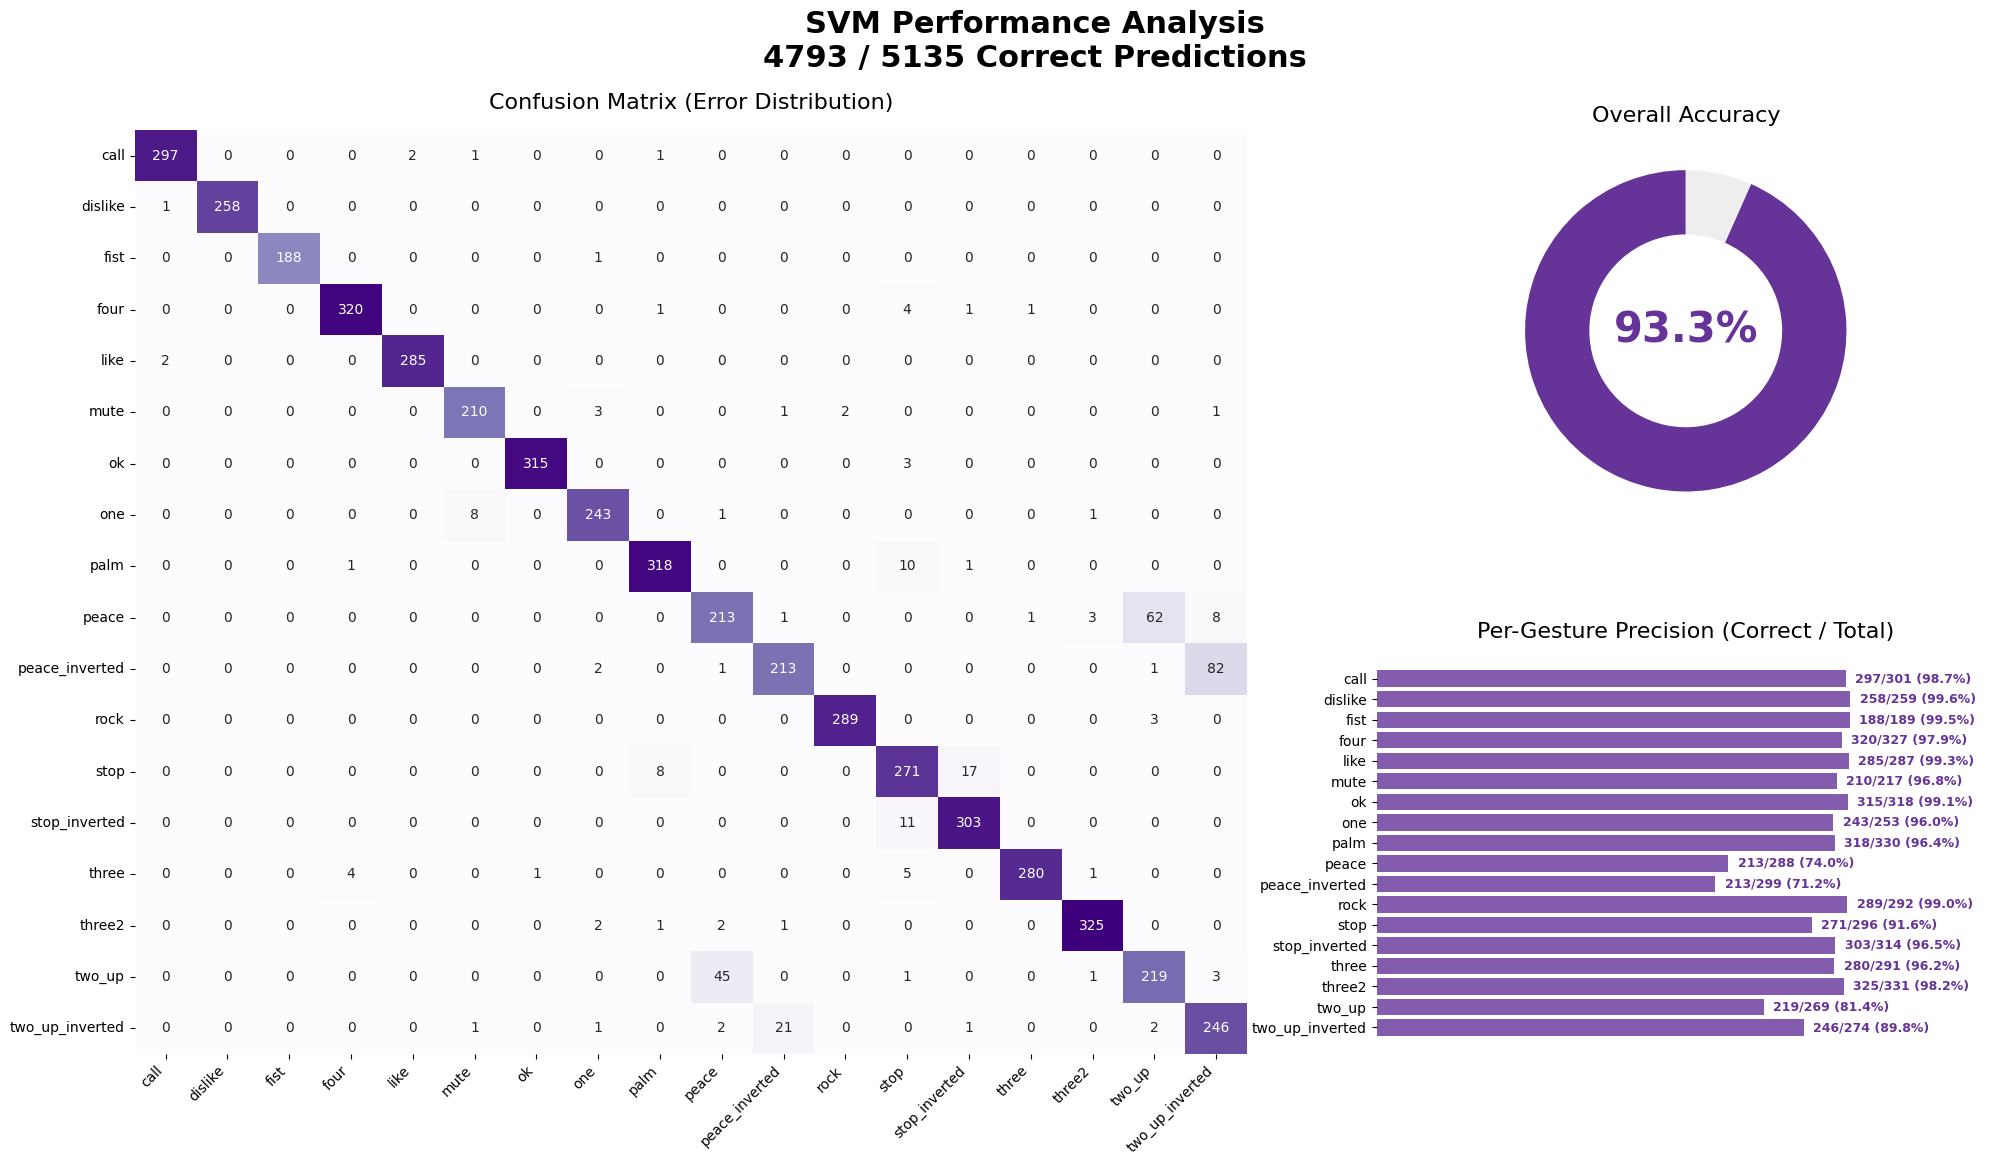

In [35]:
cm = confusion_matrix(y_test, y_pred_svm)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"SVM Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['rebeccapurple', '#eeeeee']
ax2.pie([svm_acc, 1-svm_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{svm_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='rebeccapurple')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='rebeccapurple', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='rebeccapurple')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="SVM_Baseline",
    model=svm_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=svm_params,
    metrics=svm_metrics,
    fig=fig,
    fig_name="svm_final_dashboard.png"
)

plt.show()

SVM Model 2 Poly

In [48]:
svm_opt_model = SVC(kernel='poly', degree=3, C=1.0, probability=True)
svm_opt_model.fit(X_train, y_train)

y_pred_svm_opt = svm_opt_model.predict(X_test)
svm_opt_acc = accuracy_score(y_test, y_pred_svm_opt)

svm_opt_metrics = {
    "accuracy": svm_opt_acc,
    "precision": precision_score(y_test, y_pred_svm_opt, average='weighted'),
    "recall": recall_score(y_test, y_pred_svm_opt, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_svm_opt, average='weighted')
}

svm_opt_params = {
    "kernel": "poly",
    "degree": 3,
    "C": 1.0,
    "model_type": "SVC_Optimized"
}

C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\1182928949.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:59:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:59:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'SVM_Poly_Comparison' with metrics, signature, dataset, and artifacts.


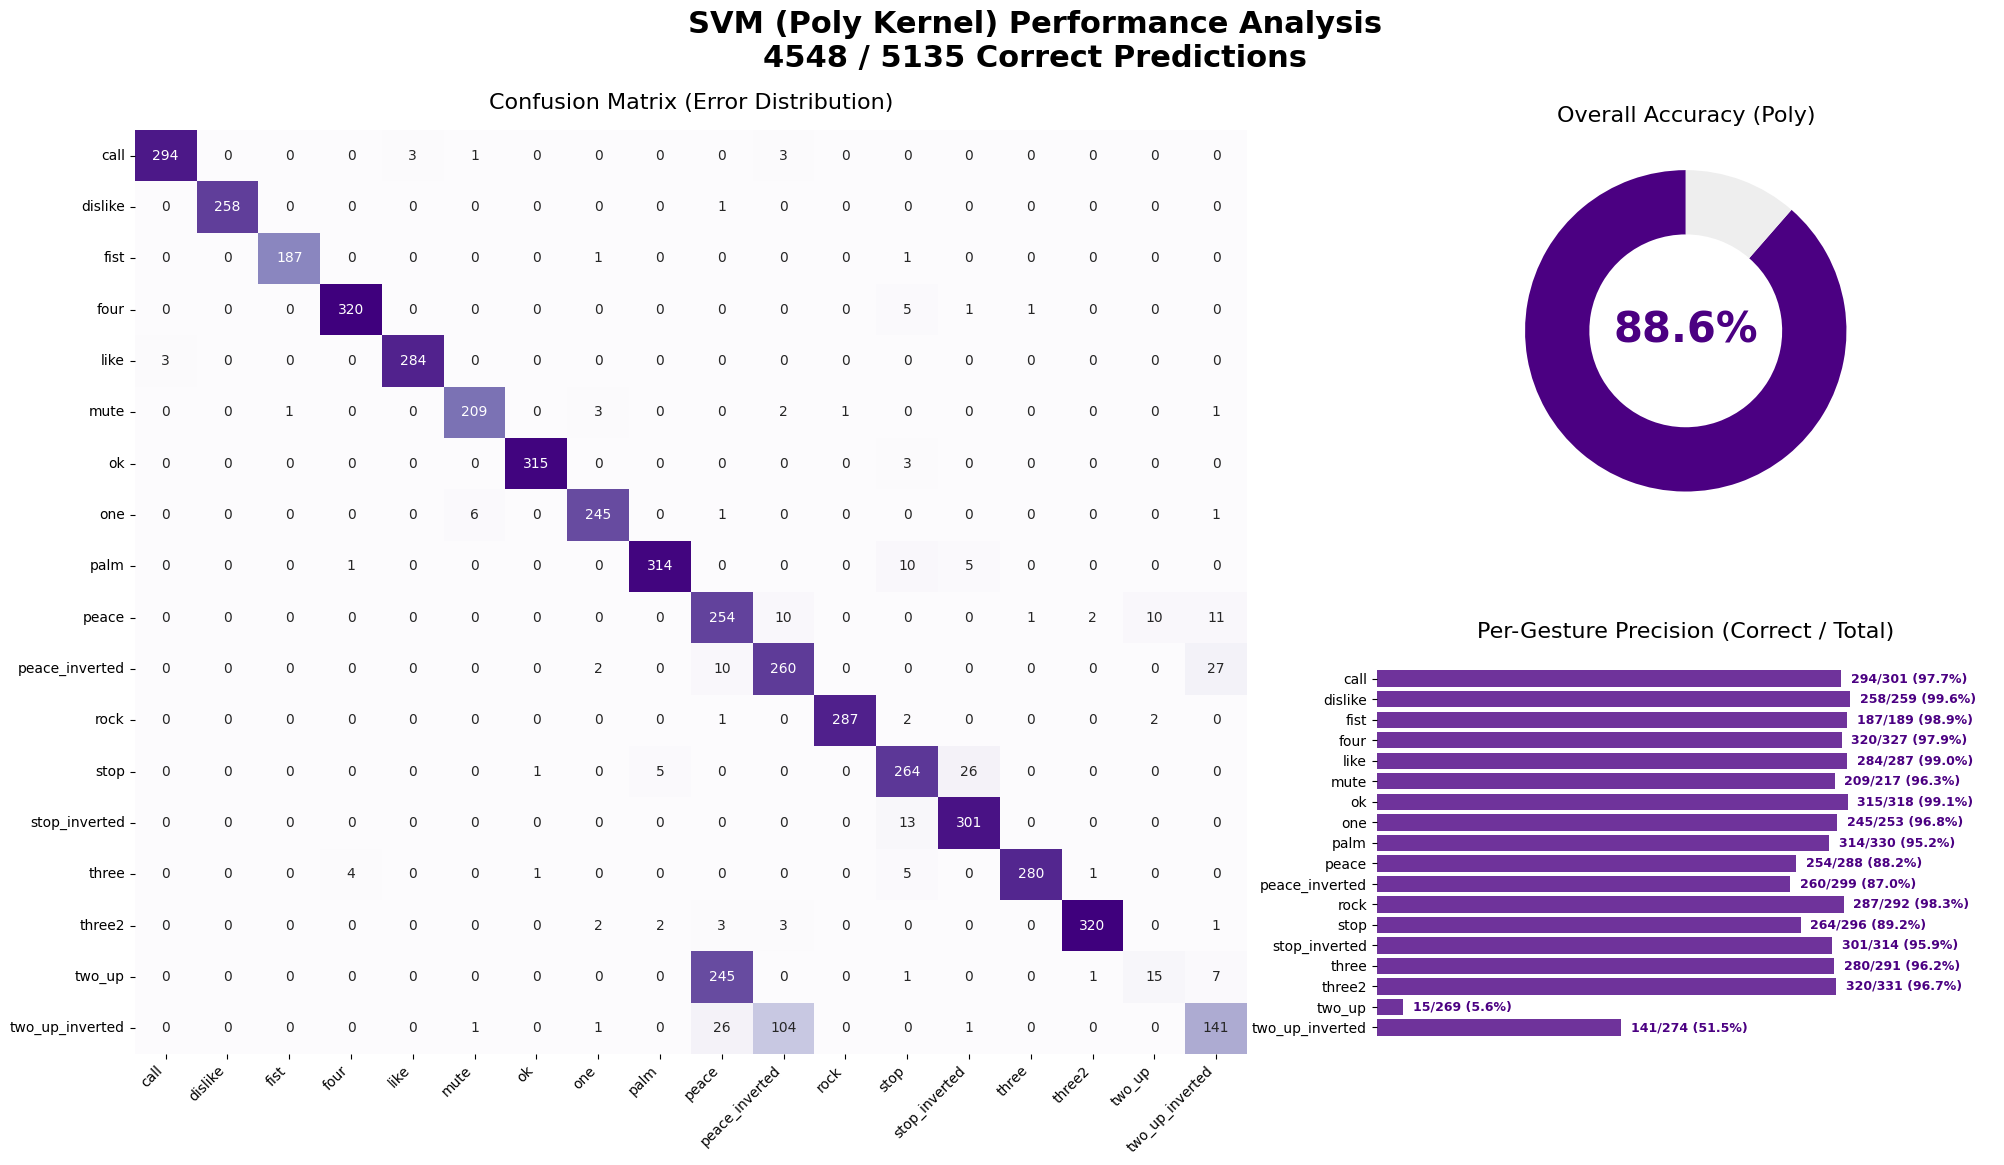

In [49]:
cm = confusion_matrix(y_test, y_pred_svm_opt)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"SVM (Poly Kernel) Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#4b0082', '#eeeeee'] 
ax2.pie([svm_opt_acc, 1-svm_opt_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{svm_opt_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#4b0082')
ax2.set_title("Overall Accuracy (Poly)", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#4b0082', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#4b0082')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="SVM_Poly_Comparison",
    model=svm_opt_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=svm_opt_params,
    metrics=svm_opt_metrics,
    fig=fig,
    fig_name="svm_poly_dashboard.png"
)

plt.show()

KNN Model

In [36]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)

knn_metrics = {
    "accuracy": knn_acc,
    "precision": precision_score(y_test, y_pred_knn, average='weighted'),
    "recall": recall_score(y_test, y_pred_knn, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_knn, average='weighted')
}

knn_params = {
    "n_neighbors": 5,
    "model_type": "KNN"
}

print(f"KNN Accuracy: {knn_acc:.4f}")

KNN Accuracy: 0.9772


C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\3313527316.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:44:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:44:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'KNN_Baseline' with metrics, signature, dataset, and artifacts.


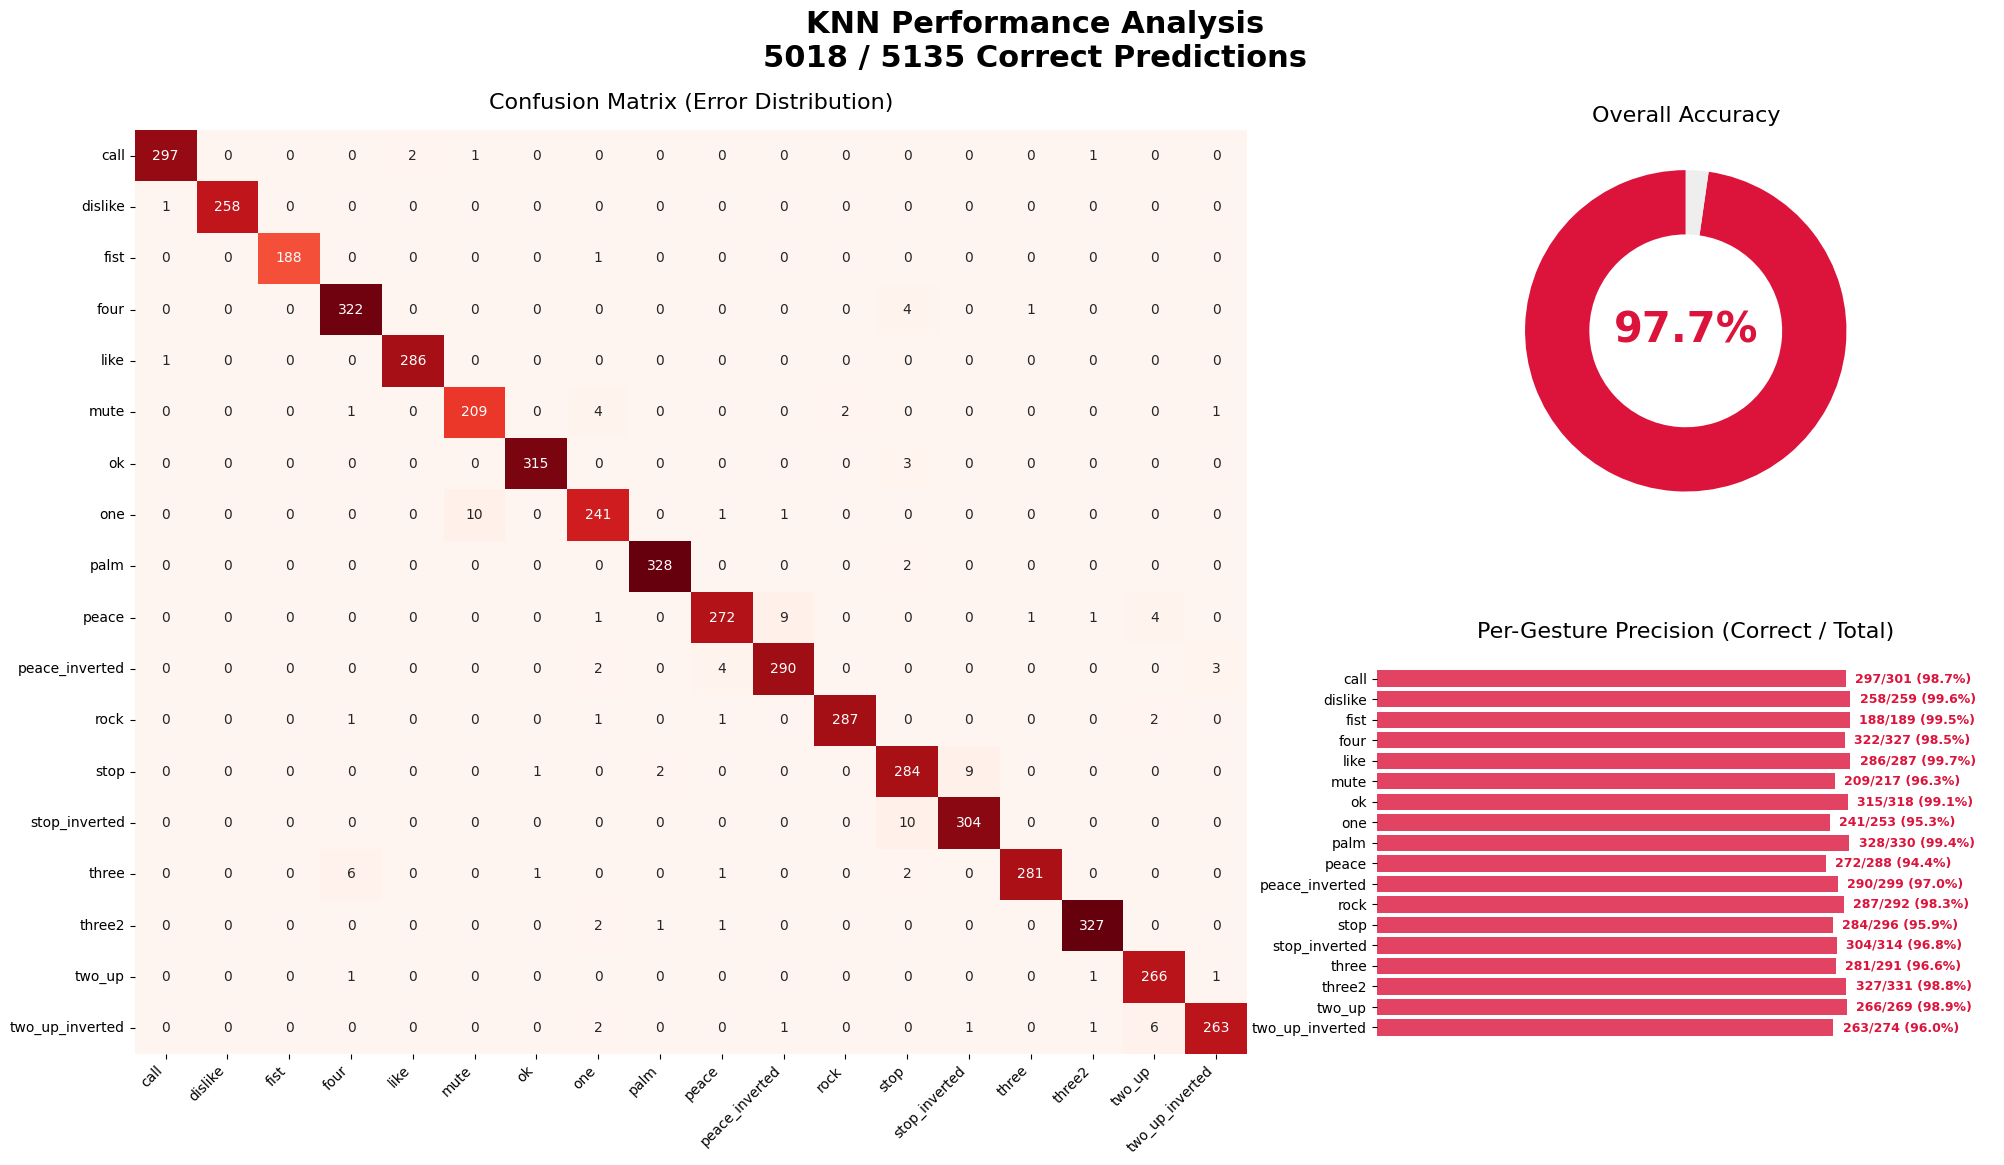

In [37]:
cm = confusion_matrix(y_test, y_pred_knn)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"KNN Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['crimson', '#eeeeee']
ax2.pie([knn_acc, 1-knn_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{knn_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='crimson')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='crimson', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='crimson')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="KNN_Baseline",
    model=knn_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=knn_params,
    metrics=knn_metrics,
    fig=fig,
    fig_name="knn_final_dashboard.png"
)

plt.show()

Adaboost Model

In [38]:
base_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
ada_model = AdaBoostClassifier(estimator=base_dt, n_estimators=100, random_state=42)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

ada_metrics = {
    "accuracy": ada_acc,
    "precision": precision_score(y_test, y_pred_ada, average='weighted'),
    "recall": recall_score(y_test, y_pred_ada, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_ada, average='weighted')
}

ada_params = {
    "base_estimator_max_depth": 3,
    "n_estimators": 100,
    "random_state": 42,
    "model_type": "AdaBoost"
}

print(f"AdaBoost Accuracy: {ada_acc:.4f}")

AdaBoost Accuracy: 0.8582


C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\4004141397.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:45:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:45:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'AdaBoost_Baseline' with metrics, signature, dataset, and artifacts.


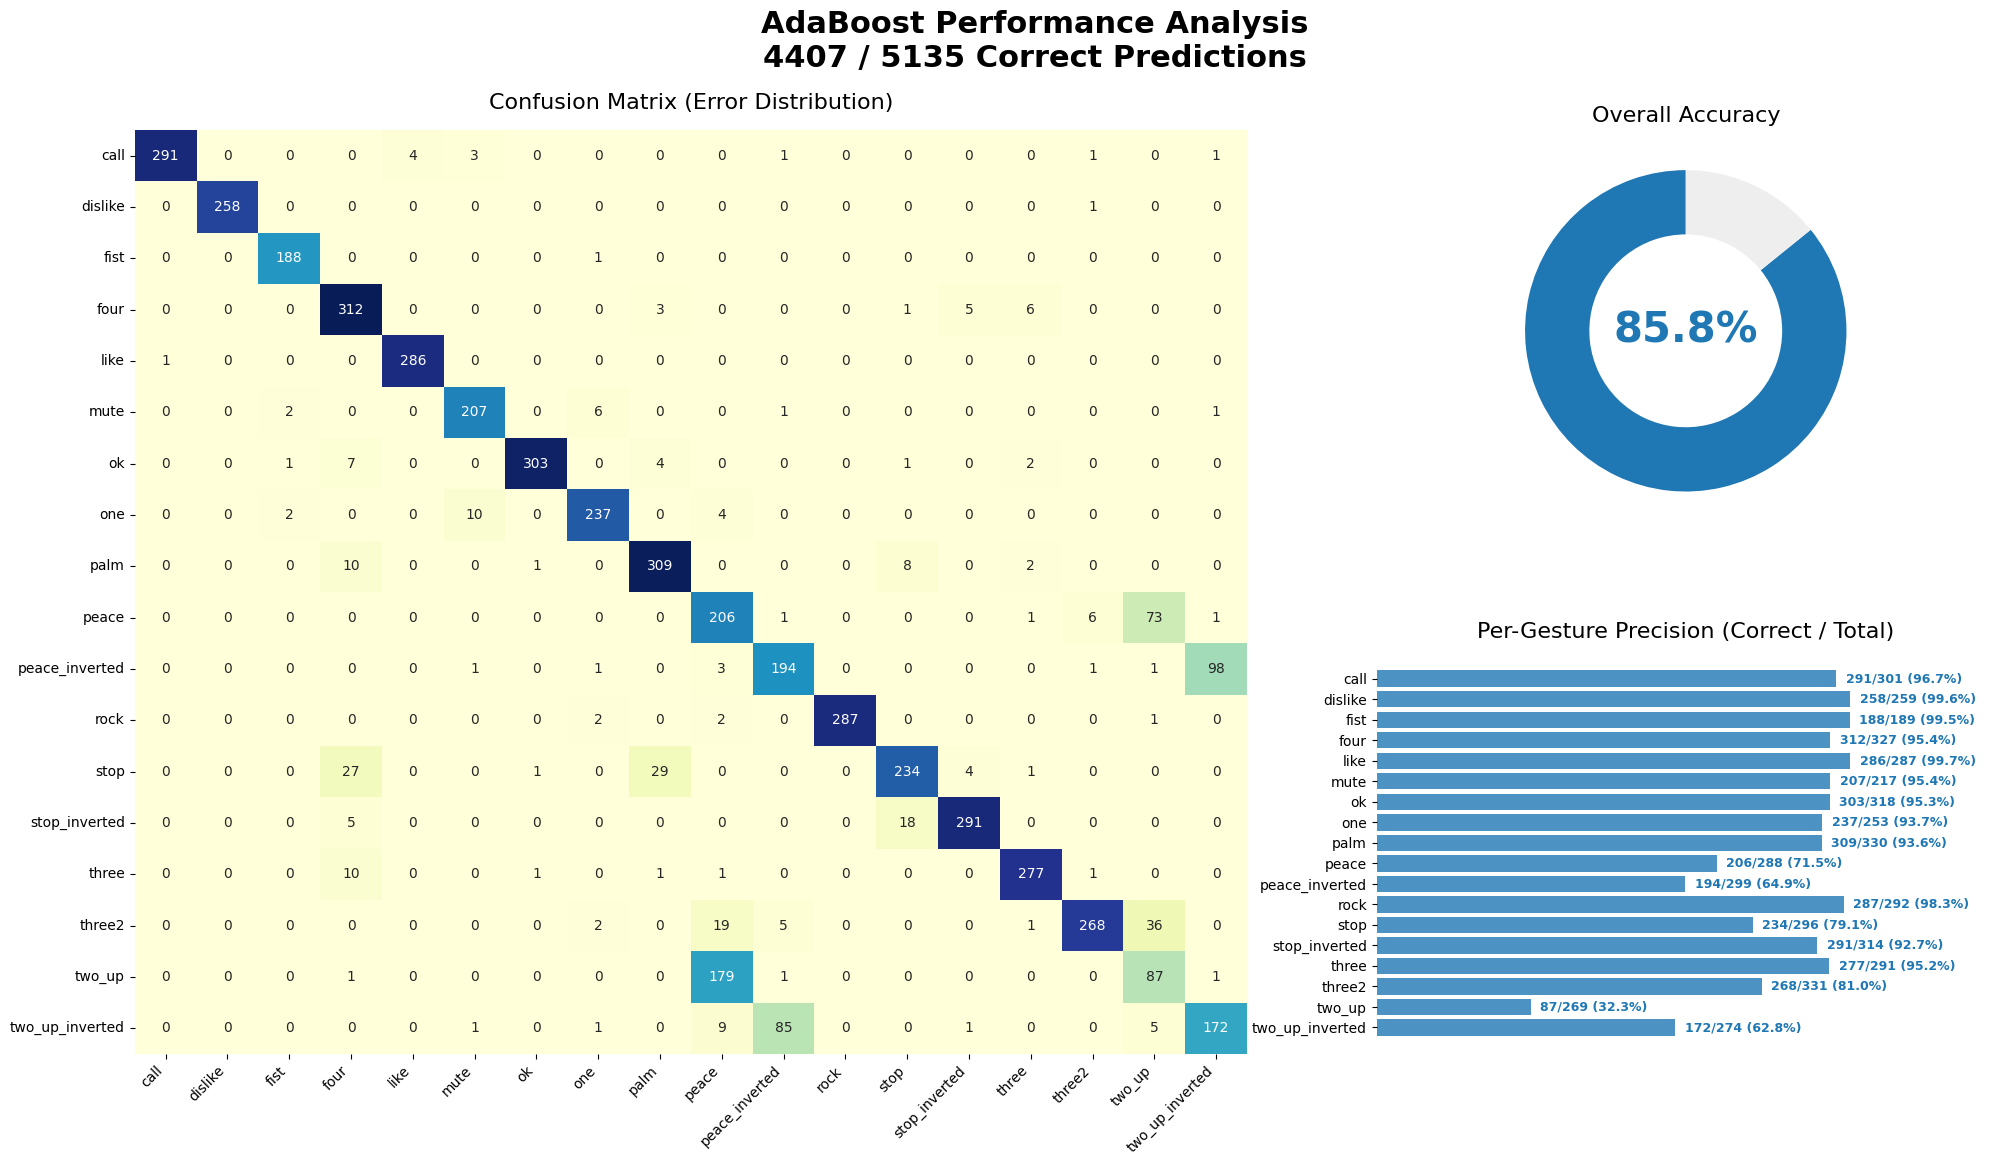

In [39]:
cm = confusion_matrix(y_test, y_pred_ada)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"AdaBoost Performance Analysis\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#1f77b4', '#eeeeee']
ax2.pie([ada_acc, 1-ada_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{ada_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#1f77b4')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#1f77b4', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#1f77b4')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="AdaBoost_Baseline",
    model=ada_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    params=ada_params,
    metrics=ada_metrics,
    fig=fig,
    fig_name="ada_final_dashboard.png"
)

plt.show()

Xgboost Model

In [40]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test_encoded, y_pred_xgb)

xgb_metrics = {
    "accuracy": xgb_acc,
    "precision": precision_score(y_test_encoded, y_pred_xgb, average='weighted'),
    "recall": recall_score(y_test_encoded, y_pred_xgb, average='weighted'),
    "f1_score": f1_score(y_test_encoded, y_pred_xgb, average='weighted')
}

xgb_params = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 5,
    "random_state": 42,
    "model_type": "XGBoost"
}
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.9799


C:\Users\asusd\AppData\Local\Temp\ipykernel_4916\2177891660.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
2026/03/01 02:45:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 02:45:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully logged: 'XGBoost_Baseline' with metrics, signature, dataset, and artifacts.


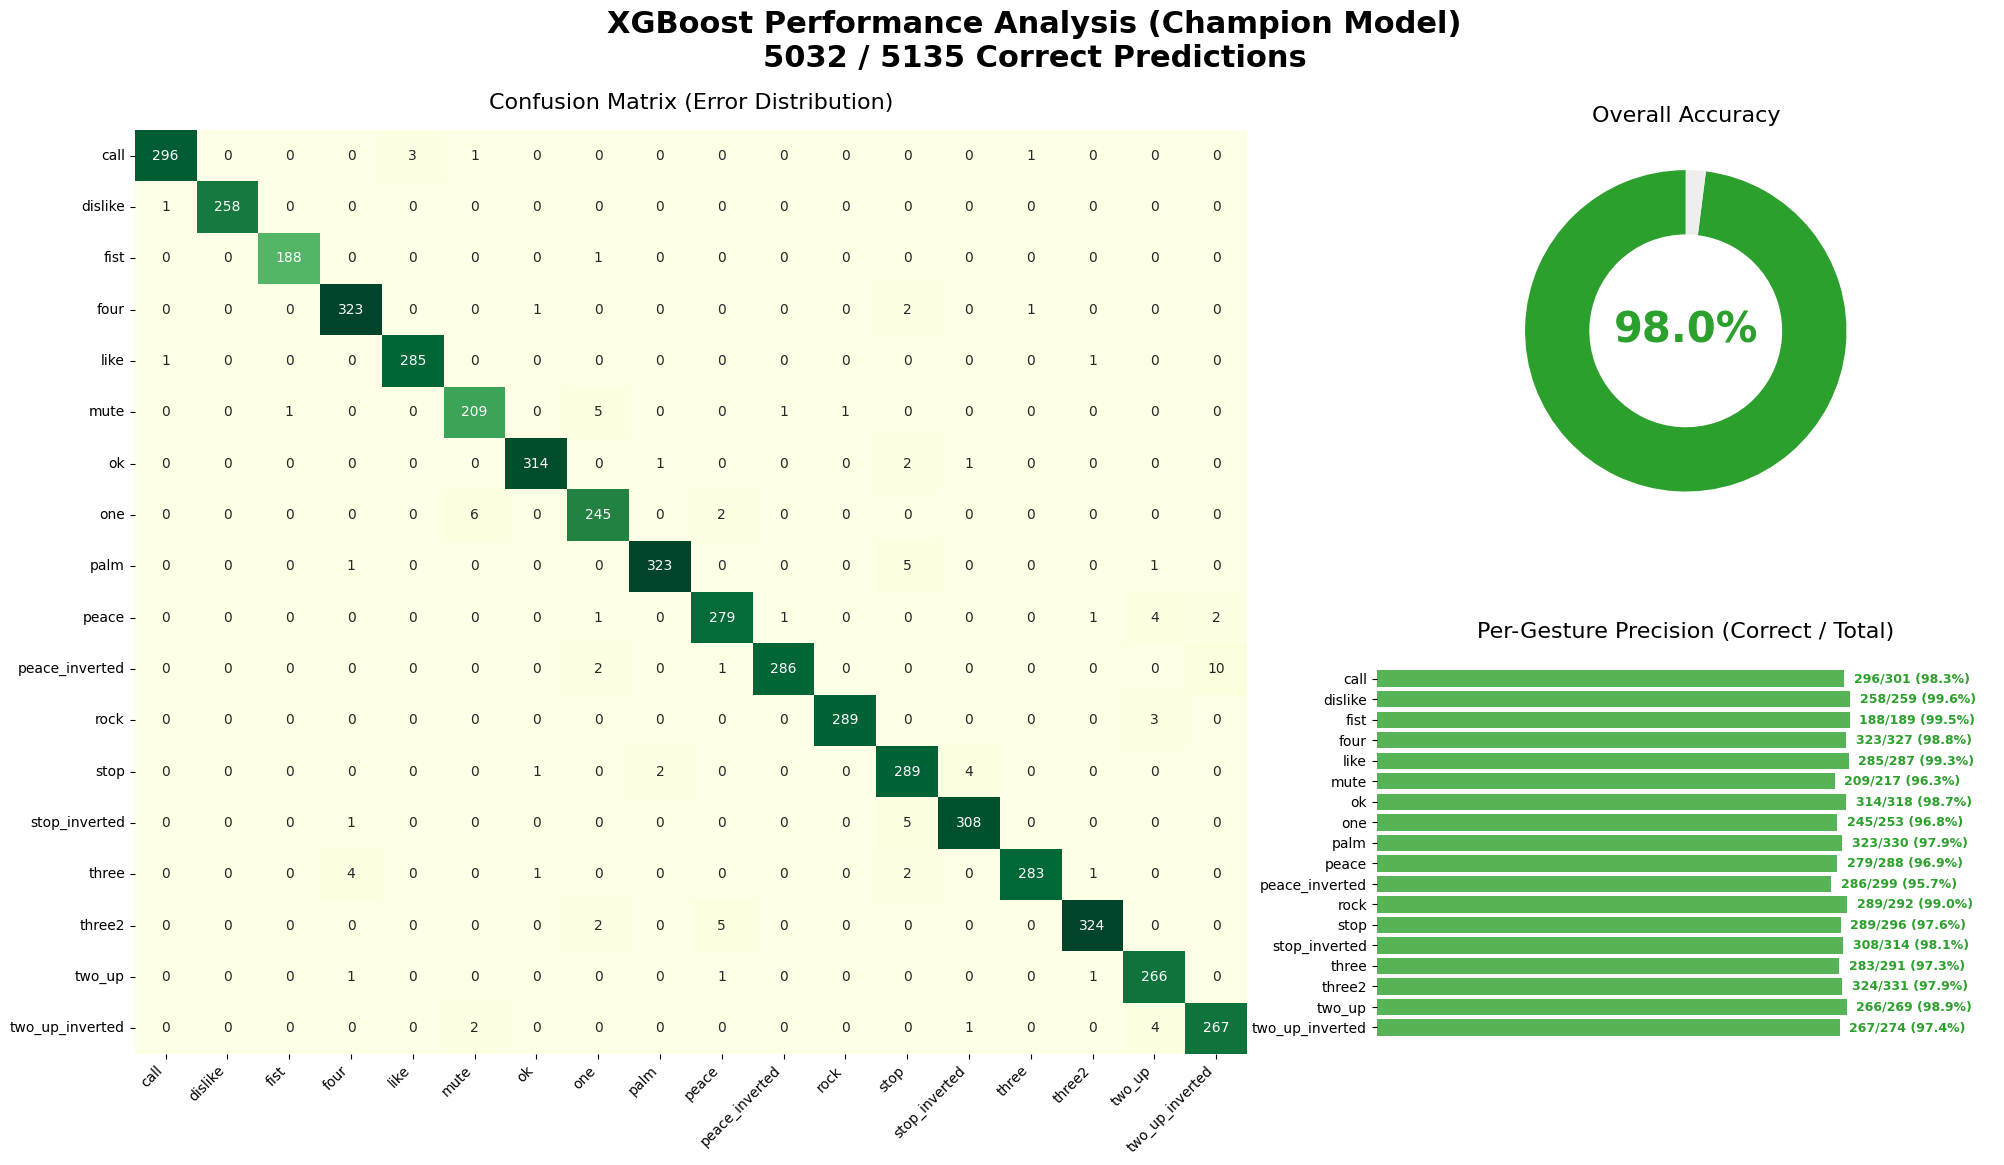

In [41]:
cm = confusion_matrix(y_test_encoded, y_pred_xgb)
class_recall = np.diag(cm) / cm.sum(axis=1)
class_totals = cm.sum(axis=1)
total_samples = len(y_test_encoded)
total_correct = np.trace(cm)

fig = plt.figure(figsize=(24, 12))
fig.suptitle(f"XGBoost Performance Analysis (Champion Model)\n{total_correct} / {total_samples} Correct Predictions", 
             fontsize=22, weight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.3)

ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', ax=ax1, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title("Confusion Matrix (Error Distribution)", fontsize=16, pad=15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = fig.add_subplot(gs[0, 1])
colors = ['#2ca02c', '#eeeeee']
ax2.pie([xgb_acc, 1-xgb_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{xgb_acc:.1%}", ha='center', va='center', fontsize=30, fontweight='bold', color='#2ca02c')
ax2.set_title("Overall Accuracy", fontsize=16)

ax3 = fig.add_subplot(gs[1, 1])
y_pos = np.arange(len(class_names))
bars = ax3.barh(y_pos, class_recall, color='#2ca02c', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names)
ax3.invert_yaxis() 
ax3.set_xlim(0, 1.3) 
ax3.set_title("Per-Gesture Precision (Correct / Total)", fontsize=16, pad=10)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{cm[i,i]}/{class_totals[i]} ({width:.1%})', 
             va='center', fontsize=9, weight='bold', color='#2ca02c')

sns.despine(ax=ax3, left=True, bottom=True)
ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

log_experiment(
    run_name="XGBoost_Baseline",
    model=xgb_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test_encoded,
    params=xgb_params,
    metrics=xgb_metrics,
    fig=fig,
    fig_name="xgb_final_dashboard.png"
)

plt.show()

Models Comparison

In [50]:
data = {
    "Model": [
        "Logistic Regression", "KNN", "SVM (Baseline)", "SVM (Poly Kernel)", 
        "Decision Tree", "Random Forest (Optimized)", "AdaBoost", "XGBoost (Champion)"
    ],
    "Accuracy": [
        lr_acc, knn_acc, svm_acc, svm_opt_acc, 
        dt_acc, rf_acc, ada_acc, xgb_acc
    ]
}

comparison_df = pd.DataFrame(data)

comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

styled_df = comparison_df.style.background_gradient(cmap='YlGn', subset=['Accuracy']).format({'Accuracy': '{:.2%}'})

print("Final Model Comparison Summary")
display(styled_df)

Final Model Comparison Summary


,Model,Accuracy
0,XGBoost (Champion),97.99%
1,Random Forest (Optimized),97.88%
2,KNN,97.72%
3,Decision Tree,95.07%
4,SVM (Baseline),93.34%
5,SVM (Poly Kernel),88.57%
6,AdaBoost,85.82%
7,Logistic Regression,85.67%


Saving the best model 

In [ ]:
import joblib
xgb_model.save_model('best_xgb_model.json')
joblib.dump(le, 'label_encoder.pkl')
print("Model and Encoder saved successfully")

Model and Encoder saved successfully
